# Lesson 2.5b — Part II：高级解析路径（选修）

Marker / LlamaParse / pdfplumber 表格调试。合并自原 `pdf_parsing2_n.ipynb`。

上一步：[05a_part1_pipeline.ipynb](05a_part1_pipeline.ipynb)  
下一步：[05c_part3_rag_compare.ipynb](05c_part3_rag_compare.ipynb)

---


---
# Part II — 高级解析路径（pdf_parsing2_n）

| 路径 | 特点 | 适用 |
|------|------|------|
| **本流水线** | 判类型 + token chunk + 元数据 | 生产默认 |
| **Marker** | DL 模型 → Markdown，可选 LLM | 复杂版面、公式 |
| **LlamaParse** | 云端 LLM 解析 | 质量优先、可联网 |
| **pdfplumber debug** | `debug_tablefinder` 手调表格线 | 难表格 |

```mermaid
flowchart LR
    A[PDF] --> B[Part I Pipeline<br/>已在上方完成]
    A --> C[pdfplumber<br/>debug_tablefinder]
    A --> D[Marker<br/>DL → Markdown]
    A --> E[LlamaParse<br/>云端 API]
    C --> F[表格线参数调优]
    D --> G[marker.md]
    E --> H[按页 Markdown 列表]
    G --> I[Part III 对比]
    H --> I
    B --> I

    style B fill:#2E7D32,color:#fff
    style C fill:#1565C0,color:#fff
    style D fill:#E65100,color:#fff
    style E fill:#6A1B9A,color:#fff
    style G fill:#EF6C00,color:#fff
    style H fill:#7B1FA2,color:#fff
    style I fill:#00695C,color:#fff
```

## 0. 安装依赖


In [ ]:
%pip install pdfplumber PyMuPDF python-dotenv -q
# 按需取消注释：
# %pip install marker-pdf
# %pip install llama-cloud-services


In [2]:
import json
import os
from pathlib import Path

import pdfplumber
from dotenv import load_dotenv

load_dotenv(override=True)

PDF_PATH = Path("doc/attention_is_all_you_need.pdf")
OUT_DIR = Path("out")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"当前 PDF: {PDF_PATH}")

当前 PDF: doc\attention_is_all_you_need.pdf


## 8. pdfplumber 表格调试（可选）

第 1 页检测到 0 张表


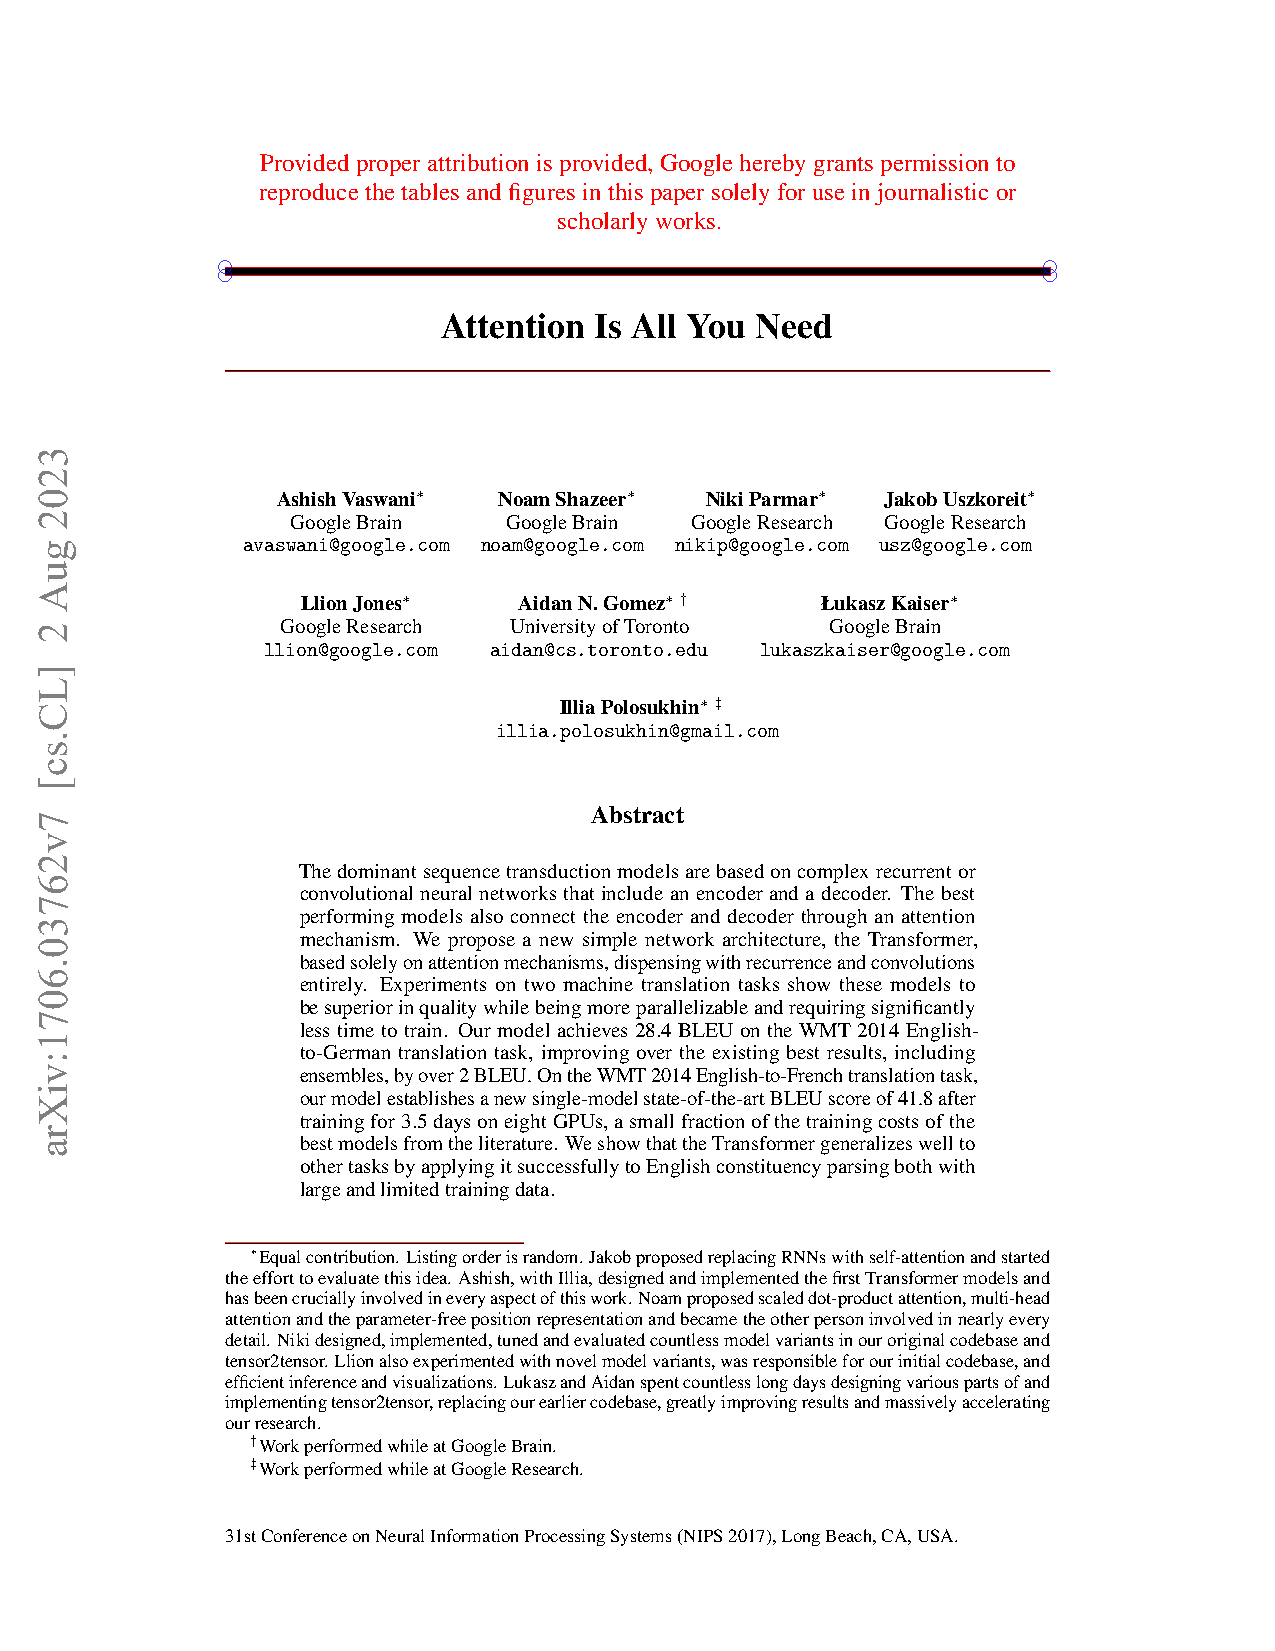

In [3]:
TABLE_DEBUG_PAGE = 0  # 含表格的页码（0-based）

try:
    import pandas as pd
    from IPython.display import display
    with pdfplumber.open(PDF_PATH) as pdf:
        if TABLE_DEBUG_PAGE < len(pdf.pages):
            pg = pdf.pages[TABLE_DEBUG_PAGE]
            tables = pg.extract_tables()
            print(f"第 {TABLE_DEBUG_PAGE+1} 页检测到 {len(tables)} 张表")
            if tables:
                df = pd.DataFrame(tables[0][1:], columns=tables[0][0])
                display(df.head())
            im = pg.to_image(resolution=150)
            display(im.debug_tablefinder())
        else:
            print("页码超出范围，跳过表格调试")
except Exception as e:
    print(f"表格调试跳过: {e}")

## 9. Marker → Markdown（可选，需 GPU/模型下载）

非商业用途免费。`use_llm=False` 为纯本地模式。

In [4]:
MARKER_PDF = PDF_PATH
marker_text = ""

try:
    from marker.converters.pdf import PdfConverter
    from marker.models import create_model_dict
    from marker.output import text_from_rendered
    from marker.config.parser import ConfigParser

    config = {
        "output_format": "markdown",
        "use_llm": False,
        "debug": False,
    }
    cp = ConfigParser(config)
    converter = PdfConverter(
        config=cp.generate_config_dict(),
        artifact_dict=create_model_dict(),
        processor_list=cp.get_processors(),
        renderer=cp.get_renderer(),
        llm_service=cp.get_llm_service(),
    )
    rendered = converter(str(MARKER_PDF))
    marker_text, _, marker_images = text_from_rendered(rendered)
    marker_md_path = OUT_DIR / f"{PDF_PATH.stem}_marker.md"
    marker_md_path.write_text(marker_text, encoding="utf-8")
    print(f"✅ Marker: {len(marker_text)} 字符 → {marker_md_path}")
    print(marker_text[:500])
except ImportError:
    print("⚠️ 未安装 marker-pdf，跳过。pip install marker-pdf")
except Exception as e:
    print(f"⚠️ Marker 失败: {e}")

C:\Users\86137\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\triton\windows_utils.py:372: UserWarning: Failed to find CUDA.
  warnings.warn("Failed to find CUDA.")


⚠️ Marker 失败: [Errno 2] No such file or directory: 'C:\\Users\\86137\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages\\transformers\\models\\deprecated\\trajectory_transformer\\convert_trajectory_transformer_original_pytorch_checkpoint_to_pytorch.py'


## 10. LlamaParse（可选，需 LLAMA_CLOUD_API_KEY）

In [ ]:
llamaparse_pages: list[str] = []

try:
    from llama_cloud_services import LlamaParse

    if not os.environ.get("LLAMA_CLOUD_API_KEY"):
        raise RuntimeError("未设置 LLAMA_CLOUD_API_KEY")

    parser = LlamaParse(result_type="markdown", split_by_page=True, verbose=True)
    result = parser.parse(str(PDF_PATH))
    llamaparse_pages = [p.text for p in result.pages]
    lp_path = OUT_DIR / f"{PDF_PATH.stem}_llamaparse.json"
    lp_path.write_text(json.dumps(llamaparse_pages, ensure_ascii=False), encoding="utf-8")
    print(f"✅ LlamaParse: {len(llamaparse_pages)} 页 → {lp_path}")
    if llamaparse_pages:
        print(llamaparse_pages[0][:400])
except ImportError:
    print("⚠️ 未安装 llama-cloud-services，跳过")
except Exception as e:
    print(f"⚠️ LlamaParse 失败: {e}")

---

✅ Part II 产出：
- `out/{pdf_stem}_marker.md`（若运行 Marker）
- `out/{pdf_stem}_llamaparse.json`（若运行 LlamaParse）
